## Initialisation

Constantes utilisées dans tout le notebook : chemin des données, seuils de décision et hyperparamètres des modèles.

In [1]:
import numpy as np

# Chemins
DATA_PATH = "artifacts/ingestions/gold/gold_splited_dataset.csv"

# Reproductibilité
RANDOM_STATE = 42

# Seuil de décision
THRESHOLD = 0.5
THRESHOLD_RANGE = np.arange(0.1, 0.51, 0.1)

# Hyperparamètres des modèles
LOG_REG_PARAMS = {"class_weight": "balanced", "max_iter": 1000}
RANDOM_FOREST_PARAMS = {"class_weight": "balanced", "random_state": RANDOM_STATE}
# XGBoost : scale_pos_weight calculé dynamiquement à partir de y_train (pas de class_weight disponible)

# Recherche d'hyperparamètres du modèle final
FINAL_THRESHOLD = 0.5
N_ESTIMATORS_RANGE = range(100, 301, 50)
MAX_DEPTH_RANGE = range(10, 21, 5)

# Hyperparamètres retenus pour le modèle final (régularisé pour limiter l'overfitting)
FINAL_N_ESTIMATORS = 150
FINAL_MAX_DEPTH = 10
FINAL_MIN_SAMPLES_LEAF = 50
FINAL_MAX_FEATURES = "log2"

# Features à faible impact (sous voltage_max_6h dans le classement SHAP) : retirées des features
LOW_IMPORTANCE_FEATURES = [
    "type_vibration_count_prev_24h",
    "temp_max_6h",
    "voltage_mean_6h",
    "voltage_mean_12h",
    "incident_count_1h",
    "voltage_mean_1h",
    "voltage_max_1h",
    "maintenance_count_prev_30d",
    "rotation_std_24h",
    "rotation_max_24h",
    "type_defaut_qualite_count_prev_24h",
    "type_baisse_pression_count_prev_24h",
    "pressure_std_24h",
    "rotation_max_12h",
    "pressure_std_12h",
    "pressure_mean_12h",
    "rotation_max_6h",
    "pressure_mean_1h",
    "pieces_produced_sum_24h",
    "pressure_max_1h",
    "type_surchauffe_count_prev_24h",
    "pieces_produced_sum_1h",
    "pressure_max_24h",
    "rotation_std_6h",
    "pressure_mean_6h",
    "type_surconsommation_count_prev_24h",
    "pressure_zscore_machine",
    "temp_mean_12h",
    "pressure_std_6h",
    "temp_zscore_machine",
    "voltage_std_24h",
    "pressure_max_12h",
    "rotation_std_12h",
    "temp_mean_6h",
    "pressure_max_6h",
    "capacity_utilization_pct",
    "rotation_mean_12h",
    "temp_max_1h",
    "temp_mean_1h",
    "temp_std_24h",
    "voltage_std_12h",
    "rotation_mean_6h",
    "voltage_trend_6h",
    "rotation_mean_1h",
    "rotation_max_1h",
    "pressure_trend_6h",
    "voltage_std_6h",
    "voltage_delta_3h",
    "temp_zscore_24h",
    "pressure_delta_3h",
    "rotation_trend_6h",
    "rotation_delta_3h",
    "temp_std_12h",
    "temp_delta_3h",
    "voltage_delta_1h",
    "temp_trend_6h",
    "temp_delta_1h",
    "temp_std_6h",
    "incident_max_severity_1h",
    "pressure_delta_1h",
    "rotation_delta_1h",
    "type_bruit_mecanique",
    "type_arret_urgence_count_prev_24h",
    "type_surchauffe",
    "type_baisse_pression",
    "type_defaut_qualite",
    "type_vibration",
    "type_blocage_mecanique_count_prev_24h",
    "type_arret_urgence",
    "type_alarme_capteur",
    "type_surconsommation",
    "type_blocage_mecanique",
]

# Validation temporelle
N_SPLITS = 5

# MLflow
MLFLOW_TRACKING_URI = "sqlite:///mlflow.db"
MLFLOW_EXPERIMENT_NAME = "predictive_maintenance"

## Chargement des données

In [2]:
import pandas as pd

df = pd.read_csv(DATA_PATH)
df.head()

,machine_id_std,window_start,temp_mean_1h,temp_max_1h,pressure_mean_1h,pressure_max_1h,voltage_mean_1h,voltage_max_1h,rotation_mean_1h,rotation_max_1h,...,maintenance_count_prev_30d,future_incident_count_6h,label_failure_next_6h,future_incident_count_12h,label_failure_next_12h,future_incident_count_24h,label_failure_next_24h,future_incident_count_48h,label_failure_next_48h,split_set
0,MACH-01,2025-06-01 00:00:00,46.340,46.340,198.203,198.203,227.568,227.568,1541.787,1541.787,...,0,0.0,False,0.0,False,0.0,False,0.0,False,train
1,MACH-01,2025-06-01 01:00:00,48.762,48.762,198.295,198.295,227.480,227.480,1537.860,1537.860,...,0,0.0,False,0.0,False,0.0,False,0.0,False,train
2,MACH-01,2025-06-01 02:00:00,51.352,51.352,199.545,199.545,228.680,228.680,1584.660,1584.660,...,0,0.0,False,0.0,False,0.0,False,0.0,False,train
3,MACH-01,2025-06-01 03:00:00,49.512,49.512,201.641,201.641,228.440,228.440,1588.960,1588.960,...,0,0.0,False,0.0,False,0.0,False,0.0,False,train
4,MACH-01,2025-06-01 04:00:00,51.982,51.982,200.157,200.157,227.840,227.840,1548.660,1548.660,...,0,0.0,False,0.0,False,0.0,False,0.0,False,train


## Suppression des colonnes et split train / validation / test

On retire les colonnes de fuite `future_incident_count_*` (comptent des incidents futurs, inconnus au moment de la prédiction) ainsi que les labels `label_failure_next_*` pour tous les horizons sauf 24h. On retire également `machine_id_std` (identifiant), `window_start`/`window_end` (dates, non utilisables telles quelles comme features numériques) et `days_since_last_maintenance`. On conserve `label_failure_next_24h` comme cible et on la renomme en `y`. On utilise ensuite le split temporel déjà fourni par `split_set` (train < validation < test) pour créer trois DataFrames distincts, sans mélange aléatoire.

In [3]:
leakage_cols = [
    "future_incident_count_6h",
    "future_incident_count_12h",
    "future_incident_count_24h",
    "future_incident_count_48h",
    "label_failure_next_6h",
    "label_failure_next_12h",
    "label_failure_next_48h",
]
id_cols = [
    "machine_id_std",
]
date_cols = [
    "window_start",
    "window_end",
]
other_cols = [
    "days_since_last_maintenance",
]

df = df.drop(columns=leakage_cols + id_cols + date_cols + other_cols + LOW_IMPORTANCE_FEATURES)
df = df.rename(columns={"label_failure_next_24h": "y"})

df_train = df[df["split_set"] == "train"].drop(columns=["split_set"])
df_validation = df[df["split_set"] == "validation"].drop(columns=["split_set"])
df_test = df[df["split_set"] == "test"].drop(columns=["split_set"])

print(f"train: {df_train.shape}")
print(f"validation: {df_validation.shape}")
print(f"test: {df_test.shape}")

train: (93990, 16)
validation: (20145, 16)
test: (20145, 16)


## Imputation des valeurs manquantes

On impute les NaN de `df_train` par la moyenne de chaque colonne (calculée sur train uniquement), puis on impute `df_validation`/`df_test` avec ces mêmes moyennes de train (pas de fuite). On construit ensuite les features/cible pour les 3 splits.

In [4]:
df_train = df_train.fillna(df_train.mean(numeric_only=True))

train_means = df_train.mean(numeric_only=True)
df_validation = df_validation.fillna(train_means)
df_test = df_test.fillna(train_means)

non_feature_cols = ["y"]
feature_cols = [col for col in df_train.columns if col not in non_feature_cols]

X_train, y_train = df_train[feature_cols], df_train["y"]
X_validation, y_validation = df_validation[feature_cols], df_validation["y"]
X_test, y_test = df_test[feature_cols], df_test["y"]

## Entraînement — modèle baseline (régression logistique)

On part d'un **modèle baseline** simple : une **régression logistique** avec les **valeurs par défaut** de scikit-learn (aucun réglage). Il sert de point de référence à améliorer par la suite.

On mesure ses performances sur le jeu de **validation**, à partir des **probabilités** de la classe positive (panne) :

- **PR-AUC** (`average_precision_score`) — aire sous la courbe précision/rappel, adaptée aux cibles **déséquilibrées** (peu de pannes) ;
- **AUC** (`roc_auc_score`) — aire sous la courbe ROC : capacité globale à **classer** une panne au-dessus d'une non-panne, indépendante du seuil.

L'entraînement est encadré par **CodeCarbon** (`EmissionsTracker`), qui estime les **émissions CO₂** (en g CO₂eq) — utile pour comparer le coût environnemental des modèles.

In [15]:
import csv
from pathlib import Path

from codecarbon import EmissionsTracker
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score

EMISSIONS_CSV = Path("emissions.csv")


def export_emissions(tracker, etape, perf):
    """Ajoute une ligne à emissions.csv : étape, durée (s), kWh, gCO2eq, perf obtenue."""
    data = tracker.final_emissions_data
    row = {
        "etape": etape,
        "duree_s": round(data.duration, 2),
        "kwh": round(data.energy_consumed, 6),
        "gco2eq": round(data.emissions * 1000, 3),
        "perf": round(float(perf), 4),
    }
    write_header = not EMISSIONS_CSV.exists()
    with EMISSIONS_CSV.open("a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=list(row))
        if write_header:
            writer.writeheader()
        writer.writerow(row)
    return row


# Modèle baseline : régression logistique avec les valeurs par défaut de scikit-learn
baseline_model = LogisticRegression()

# Suivi des émissions CO2 de l'entraînement (CodeCarbon)
tracker = EmissionsTracker(project_name="baseline_logreg", log_level="error", save_to_file=False)
tracker.start()
baseline_model.fit(X_train, y_train)
tracker.stop()

# Probabilités de la classe positive (panne) sur la validation
y_val_proba = baseline_model.predict_proba(X_validation)[:, 1]
pr_auc = average_precision_score(y_validation, y_val_proba)  # aire précision/rappel (cible déséquilibrée)
auc = roc_auc_score(y_validation, y_val_proba)               # AUC (aire sous la courbe ROC)

# Export d'une ligne dans emissions.csv (perf = PR-AUC validation)
row = export_emissions(tracker, "baseline_logreg", pr_auc)

print("Baseline — régression logistique (paramètres par défaut)")
print(f"PR-AUC (validation) : {pr_auc:.3f}")
print(f"AUC    (validation) : {auc:.3f}")
print(f"Émissions -> {row['gco2eq']} g CO2eq | {row['kwh']} kWh | {row['duree_s']} s  (ajouté à {EMISSIONS_CSV})")

[codecarbon WARNING @ 16:16:22] Multiple instances of codecarbon are allowed to run at the same time.
/Users/avallet/formation-ia-project/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Baseline — régression logistique (paramètres par défaut)
PR-AUC (validation) : 0.537
AUC    (validation) : 0.744
Émissions -> 0.0 g CO2eq | 2e-06 kWh | 4.57 s  (ajouté à emissions.csv)


## Amélioration — recherche d'hyperparamètres XGBoost (Optuna + CV temporelle + pruning)

Au-delà du baseline linéaire, on **recherche les meilleurs hyperparamètres** d'un **XGBoost** avec **Optuna**. La fonction `objective(trial)` :

1. **échantillonne** les hyperparamètres dans les intervalles ci-dessous,
2. **entraîne et évalue** le modèle en **validation croisée temporelle** (`TimeSeriesSplit` sur `X_train` : chaque pli entraîne sur le passé, valide sur le futur),
3. **renvoie la PR-AUC moyenne sur les plis** (l'AUC moyenne est gardée en *user attribute* pour le tableau).

La `study` est configurée avec :
- **sampler TPE** (bayésien, graine fixée → reproductible),
- **pruner `MedianPruner`** : après **chaque pli**, on transmet la PR-AUC moyenne courante (`trial.report`) ; si l'essai est **sous la médiane** des essais précédents au même stade, il est **abandonné** (`should_prune`) → on économise les plis restants sur les combinaisons peu prometteuses.

L'objectif est la **PR-AUC en CV temporelle** — **pas** une évaluation sur validation/test, réservés à l'évaluation finale (pas de fuite dans la sélection).

Intervalles proposés (adaptés à ~94k lignes, cible déséquilibrée) :

| Hyperparamètre | Intervalle | Rôle |
|----------------|-----------|------|
| `n_estimators` | 100 – 800 | nombre d'arbres (plus = plus de capacité, plus lent) |
| `max_depth` | 3 – 10 | profondeur des arbres (complexité / sur-apprentissage) |
| `learning_rate` | 1e-3 – 0.3 *(log)* | pas d'apprentissage (petit = plus stable mais + d'arbres) |
| `subsample` | 0.5 – 1.0 | fraction de lignes par arbre (régularisation) |
| `colsample_bytree` | 0.5 – 1.0 | fraction de features par arbre (régularisation) |
| `min_child_weight` | 1 – 10 | poids minimal d'une feuille (contre le sur-apprentissage) |
| `gamma` | 0 – 5 | gain minimal pour créer un split (élagage) |
| `reg_alpha` | 1e-8 – 10 *(log)* | régularisation **L1** (parcimonie) |
| `reg_lambda` | 1e-8 – 10 *(log)* | régularisation **L2** (lissage) |
| `scale_pos_weight` | 1 – 2×ratio | poids de la classe positive → gère le **déséquilibre** (`ratio` = nég/pos) |

> Le pruner ne se déclenche qu'après `n_startup_trials=5` essais complets (il lui faut une base de comparaison) et `n_warmup_steps=1` pli. La cellule **ne réentraîne pas** de modèle final ; elle affiche la meilleure PR-AUC CV, le nombre d'essais élagués et les hyperparamètres correspondants.

In [16]:
import numpy as np
import optuna
from codecarbon import EmissionsTracker
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBClassifier

# Ratio de déséquilibre (négatifs / positifs) : repère pour scale_pos_weight
neg_pos_ratio = (y_train == False).sum() / (y_train == True).sum()
print(f"Ratio négatifs/positifs (train) : {neg_pos_ratio:.1f}")

# Validation croisée temporelle sur X_train (entraîne sur le passé, valide sur le futur)
tscv = TimeSeriesSplit(n_splits=N_SPLITS)


def objective_xgb(trial):
    # 1. Échantillonnage des hyperparamètres
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),          # nb d'arbres
        "max_depth": trial.suggest_int("max_depth", 3, 10),                   # profondeur (complexité)
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),  # pas d'apprentissage
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),             # fraction de lignes / arbre
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),  # fraction de features / arbre
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),    # poids min d'une feuille
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),                     # gain min pour splitter
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),  # régularisation L1
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),  # régularisation L2
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1.0, 2 * neg_pos_ratio),  # déséquilibre
    }

    # 2. Entraînement + évaluation sur chaque pli temporel, avec PRUNING au fil des plis
    pr_aucs, aucs = [], []
    for step, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
        X_tr, X_va = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]
        model = XGBClassifier(**params, random_state=RANDOM_STATE)
        model.fit(X_tr, y_tr)
        proba = model.predict_proba(X_va)[:, 1]
        pr_aucs.append(average_precision_score(y_va, proba))
        aucs.append(roc_auc_score(y_va, proba))

        # Score intermédiaire (PR-AUC moyenne jusqu'ici) transmis au pruner
        trial.report(float(np.mean(pr_aucs)), step)
        if trial.should_prune():                 # essai sous la médiane des précédents -> abandonné
            raise optuna.TrialPruned()

    # 3. On renvoie la PR-AUC MOYENNE en CV (AUC moyenne gardée pour le tableau)
    trial.set_user_attr("auc", float(np.mean(aucs)))
    return float(np.mean(pr_aucs))


optuna.logging.set_verbosity(optuna.logging.WARNING)
study_xgb = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1),  # élague les essais peu prometteurs
)

# Suivi des émissions CO2 de toute la recherche d'hyperparamètres (CodeCarbon)
tracker = EmissionsTracker(project_name="xgb_optuna_search", log_level="error", save_to_file=False)
tracker.start()
study_xgb.optimize(objective_xgb, n_trials=30, show_progress_bar=True)
tracker.stop()

# Décompte des essais complets / élagués par le pruner
n_complete = sum(t.state == optuna.trial.TrialState.COMPLETE for t in study_xgb.trials)
n_pruned = sum(t.state == optuna.trial.TrialState.PRUNED for t in study_xgb.trials)

# Export d'une ligne dans emissions.csv (perf = meilleure PR-AUC CV)
row = export_emissions(tracker, "xgb_optuna_search", study_xgb.best_value)

# Restitution des meilleures valeurs (aucun réentraînement)
print(f"\nEssais : {n_complete} complets, {n_pruned} élagués (MedianPruner)")
print(f"Meilleure PR-AUC (CV temporelle) : {study_xgb.best_value:.3f}  (baseline sur validation : {pr_auc:.3f})")
print(f"AUC moyenne de ce meilleur essai : {study_xgb.best_trial.user_attrs['auc']:.3f}")
print(f"Émissions -> {row['gco2eq']} g CO2eq | {row['kwh']} kWh | {row['duree_s']} s  (ajouté à {EMISSIONS_CSV})")
print("Meilleurs hyperparamètres :")
for name, value in study_xgb.best_params.items():
    print(f"  {name:<18}: {value}")

Ratio négatifs/positifs (train) : 5.0


  0%|          | 0/30 [00:00<?, ?it/s]


Essais : 22 complets, 8 élagués (MedianPruner)
Meilleure PR-AUC (CV temporelle) : 0.540  (baseline sur validation : 0.537)
AUC moyenne de ce meilleur essai : 0.749
Émissions -> 0.102 g CO2eq | 0.001817 kWh | 107.15 s  (ajouté à emissions.csv)
Meilleurs hyperparamètres :
  n_estimators      : 603
  max_depth         : 3
  learning_rate     : 0.004486347145236872
  subsample         : 0.8271064551584807
  colsample_bytree  : 0.7600054921712823
  min_child_weight  : 8
  gamma             : 4.933612867440569
  reg_alpha         : 1.1811634526922578e-08
  reg_lambda        : 1.8484284551913724e-05
  scale_pos_weight  : 1.0468795314652257


## Détail des essais Optuna

On récapitule la recherche dans un tableau : **une ligne par essai**, avec **tous les hyperparamètres testés** et les **deux scores moyens en CV temporelle** — `pr_auc` (l'objectif optimisé) et `auc` (gardée en *user attribute*). Le tableau est trié par `pr_auc` décroissante — le meilleur essai est en tête. Utile pour voir quelles valeurs d'hyperparamètres mènent aux meilleurs scores et repérer d'éventuelles tendances.

In [ ]:
import pandas as pd

# Un tableau : une ligne par essai Optuna, tous les hyperparamètres + PR-AUC, AUC et état
trials_df = study_xgb.trials_dataframe(attrs=("number", "value", "state", "params", "user_attrs"))
trials_df = trials_df.rename(columns={"number": "essai", "value": "pr_auc", "state": "etat", "user_attrs_auc": "auc"})
trials_df.columns = [c.replace("params_", "") for c in trials_df.columns]

# Arrondis lisibles + tri par PR-AUC décroissante (essais élagués -> pr_auc NaN, rejetés en bas)
for col in ["learning_rate", "subsample", "colsample_bytree", "gamma", "reg_alpha", "reg_lambda", "scale_pos_weight"]:
    trials_df[col] = trials_df[col].round(4)
trials_df[["pr_auc", "auc"]] = trials_df[["pr_auc", "auc"]].round(4)
trials_df = trials_df.sort_values("pr_auc", ascending=False, na_position="last").reset_index(drop=True)

# Colonnes ordonnées : essai, état, scores, puis hyperparamètres
head_cols = ["essai", "etat", "pr_auc", "auc"]
trials_df = trials_df[head_cols + [c for c in trials_df.columns if c not in head_cols]]

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
trials_df

## Slice plot des hyperparamètres dominants

On identifie d'abord les **hyperparamètres les plus influents** (`optuna.importance.get_param_importances`, méthode fANOVA), puis on trace le **slice plot** des 2-3 premiers : pour chaque HP, un nuage **valeur testée → PR-AUC obtenue**.

Lecture : la **forme du nuage** révèle la plage qui marche le mieux pour chaque HP (ex. la PR-AUC monte quand `max_depth` baisse). C'est ce qui permet de **resserrer les intervalles** pour une recherche plus fine ensuite. On se limite aux HP dominants pour ne pas noyer l'information sous les paramètres négligeables.

In [ ]:
import matplotlib.pyplot as plt
import optuna
import optuna.visualization.matplotlib as ovm

# Les hyperparamètres les plus influents (importance fANOVA sur les essais complets)
importances = optuna.importance.get_param_importances(study_xgb)
top_params = list(importances)[:3]
print("HP dominants :", top_params)

# Slice plot : PR-AUC en fonction de la valeur de chaque HP dominant
ovm.plot_slice(study_xgb, params=top_params)
plt.tight_layout()
plt.show()

## Coût carbone vs gain : deux stratégies de recherche

On compare **deux façons de chercher les hyperparamètres**, chacune mesurée par CodeCarbon (ligne ajoutée à `emissions.csv`) :

- **(a) exploratoire** — **grand** espace de recherche, **40 essais**, **sans pruning** : on ratisse large, coûteux ;
- **(b) ciblée** — espace **resserré** (autour de la zone prometteuse : arbres peu profonds, learning rate faible), **pruning agressif** (`MedianPruner(n_startup_trials=3, n_warmup_steps=0)`), **15 essais** : rapide et frugal.

Pour chaque stratégie, on calcule le **coût par point de PR-AUC gagné** par rapport à la **baseline** (1 point = 0,01 de PR-AUC) :

$$\text{coût/point} = \frac{\text{gCO}_2\text{eq de la recherche}}{(\text{PR-AUC}_{\text{best}} - \text{PR-AUC}_{\text{baseline}}) \times 100}$$

Cet indicateur mesure l'**efficience** : combien de CO₂ (ou de kWh) chaque dixième de point de performance a coûté. Il permet d'arbitrer entre « chercher plus » et « chercher mieux ».

> ⚠️ Coûteux : (a) 40 essais × 5 plis = 200 entraînements XGBoost (sans pruning), (b) jusqu'à 15 × 5 mais fortement élagués. La baseline sert de référence mais est mesurée sur validation (les recherches sont en CV) : comparaison indicative, pas strictement homogène.

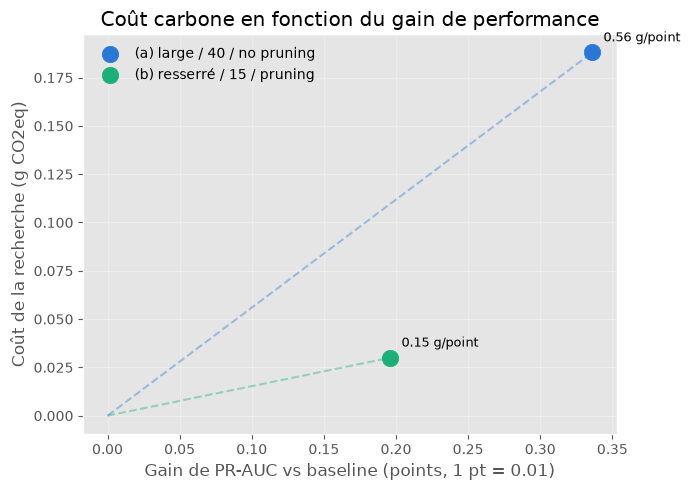

Baseline PR-AUC (référence) : 0.537


In [18]:
import numpy as np
import optuna
import pandas as pd
import matplotlib.pyplot as plt
from codecarbon import EmissionsTracker
from sklearn.metrics import average_precision_score
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBClassifier

tscv = TimeSeriesSplit(n_splits=N_SPLITS)
neg_pos_ratio = (y_train == False).sum() / (y_train == True).sum()


# --- (a) Grand espace de recherche ---
def space_large(trial):
    return {
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1.0, 2 * neg_pos_ratio),
    }


# --- (b) Espace resserré (autour de la zone prometteuse : arbres peu profonds, LR faible) ---
def space_tight(trial):
    return {
        "n_estimators": trial.suggest_int("n_estimators", 400, 700),
        "max_depth": trial.suggest_int("max_depth", 3, 5),
        "learning_rate": trial.suggest_float("learning_rate", 3e-3, 3e-2, log=True),
        "subsample": trial.suggest_float("subsample", 0.7, 0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 0.9),
        "min_child_weight": trial.suggest_int("min_child_weight", 6, 10),
        "gamma": trial.suggest_float("gamma", 3.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 1.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 1.0, log=True),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1.0, 2.0),
    }


def cv_pr_auc(params, trial):
    """PR-AUC moyenne en CV temporelle, avec report/pruning au fil des plis."""
    pr_aucs = []
    for step, (tr, va) in enumerate(tscv.split(X_train)):
        model = XGBClassifier(**params, random_state=RANDOM_STATE)
        model.fit(X_train.iloc[tr], y_train.iloc[tr])
        proba = model.predict_proba(X_train.iloc[va])[:, 1]
        pr_aucs.append(average_precision_score(y_train.iloc[va], proba))
        trial.report(float(np.mean(pr_aucs)), step)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return float(np.mean(pr_aucs))


def run_config(name, space, n_trials, pruner):
    """Lance une étude Optuna (mesurée par CodeCarbon) et exporte une ligne dans emissions.csv."""
    study = optuna.create_study(
        direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE), pruner=pruner,
    )
    tracker = EmissionsTracker(project_name=name, log_level="error", save_to_file=False)
    tracker.start()
    study.optimize(lambda t: cv_pr_auc(space(t), t), n_trials=n_trials)
    tracker.stop()
    row = export_emissions(tracker, name, study.best_value)
    return study, row


optuna.logging.set_verbosity(optuna.logging.WARNING)

# (a) grand espace + 40 essais + SANS pruning
study_a, row_a = run_config("a_large_40_nopruning", space_large, 40, optuna.pruners.NopPruner())
# (b) espace resserré + pruning AGRESSIF + 15 essais
pruner_agressif = optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=0)
study_b, row_b = run_config("b_tight_15_pruning", space_tight, 15, pruner_agressif)

# Gain (points de PR-AUC vs baseline) et coût de chaque stratégie
points = {
    "(a) large / 40 / no pruning": row_a,
    "(b) resserré / 15 / pruning": row_b,
}
colors = {"(a) large / 40 / no pruning": "#2a78d6", "(b) resserré / 15 / pruning": "#1baf7a"}

# --- Graphe : gain de points (x) vs coût carbone (y) ---
fig, ax = plt.subplots(figsize=(7, 5))
for label, row in points.items():
    gain_pts = (row["perf"] - pr_auc) * 100          # 1 point = 0.01 de PR-AUC
    cost = row["gco2eq"]
    ax.plot([0, gain_pts], [0, cost], "--", color=colors[label], alpha=0.4, zorder=1)  # pente = coût/point
    ax.scatter(gain_pts, cost, s=140, color=colors[label], zorder=3, label=label)
    cpp = cost / gain_pts if gain_pts > 0 else float("nan")
    ax.annotate(f"{cpp:.2f} g/point", (gain_pts, cost),
                textcoords="offset points", xytext=(8, 8), fontsize=9)

ax.set_xlabel("Gain de PR-AUC vs baseline (points, 1 pt = 0.01)")
ax.set_ylabel("Coût de la recherche (g CO2eq)")
ax.set_title("Coût carbone en fonction du gain de performance")
ax.legend(frameon=False)
ax.grid(alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

print(f"Baseline PR-AUC (référence) : {pr_auc:.3f}")


## Vérification du déséquilibre de la cible

On mesure le déséquilibre de `y` sur les 3 splits (train, validation, test) — il doit rester similaire d'un split à l'autre puisque le split est temporel, pas aléatoire.

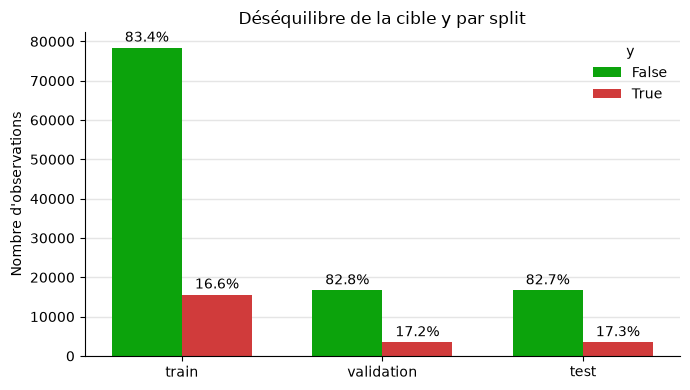

In [6]:
import matplotlib.pyplot as plt
import numpy as np

splits = {"train": df_train, "validation": df_validation, "test": df_test}
status_colors = {False: "#0ca30c", True: "#d03b3b"}  # good (pas de panne) / critical (panne)

imbalance_df = pd.DataFrame({
    split_name: split_df["y"].value_counts().reindex([False, True])
    for split_name, split_df in splits.items()
})
imbalance_pct = (imbalance_df / imbalance_df.sum() * 100).round(1)

x = np.arange(len(splits))
width = 0.35

fig_imbalance, ax = plt.subplots(figsize=(7, 4))
for i, label in enumerate([False, True]):
    offset = (i - 0.5) * width
    bars = ax.bar(x + offset, imbalance_df.loc[label], width, label=str(label), color=status_colors[label])
    ax.bar_label(bars, labels=[f"{p}%" for p in imbalance_pct.loc[label]], padding=2)

ax.set_xticks(x, list(splits.keys()))
ax.set_ylabel("Nombre d'observations")
ax.set_title("Déséquilibre de la cible y par split")
ax.legend(title="y", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.grid(True, color="#e5e5e5", linewidth=1)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## Validation temporelle (TimeSeriesSplit)

On valide la robustesse des 3 modèles avec `TimeSeriesSplit` sur `df_train` : chaque fold entraîne sur le passé et valide sur une période future, respectant l'ordre chronologique (contrairement à une k-fold classique qui mélangerait les données).

In [54]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import average_precision_score

tscv = TimeSeriesSplit(n_splits=N_SPLITS)

cv_results = []
for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train), start=1):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    for model_name, model in [
        ("Logistic Regression", LogisticRegression(**LOG_REG_PARAMS)),
        ("Random Forest", RandomForestClassifier(**RANDOM_FOREST_PARAMS)),
        ("XGBoost", XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE)),
    ]:
        model.fit(X_fold_train, y_fold_train)
        y_proba = model.predict_proba(X_fold_val)[:, 1]
        cv_results.append({
            "fold": fold,
            "model": model_name,
            "pr_auc": average_precision_score(y_fold_val, y_proba),
        })

pd.DataFrame(cv_results).pivot(index="fold", columns="model", values="pr_auc").style.format("{:.2f}")

/Users/avallet/formation-ia-project/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/avallet/formation-ia-project/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://sciki

model,Logistic Regression,Random Forest,XGBoost
fold,,,
1,0.49,0.55,0.52
2,0.29,0.35,0.42
3,0.44,0.51,0.46
4,0.50,0.57,0.54
5,0.50,0.60,0.61


## PR-AUC des 3 modèles sur validation et test

In [7]:
import numpy as np
from sklearn.metrics import average_precision_score

pr_auc_results = []
for split_name, X, y_true in [
    ("validation", X_validation, y_validation),
    ("test", X_test, y_test),
]:
    for model_name, model in [
        ("Logistic Regression", log_reg),
        ("Random Forest", random_forest),
        ("XGBoost", xgboost_model),
    ]:
        y_proba = model.predict_proba(X)[:, 1]
        pr_auc_results.append({
            "split": split_name,
            "model": model_name,
            "pr_auc": average_precision_score(y_true, y_proba),
        })

pr_auc_df = pd.DataFrame(pr_auc_results).pivot(index="model", columns="split", values="pr_auc")

splits = ["validation", "test"]
split_colors = {"validation": "#2a78d6", "test": "#1baf7a"}
x = np.arange(len(pr_auc_df.index))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
for i, split_name in enumerate(splits):
    offset = (i - 0.5) * width
    bars = ax.bar(x + offset, pr_auc_df[split_name], width, label=split_name, color=split_colors[split_name])
    ax.bar_label(bars, fmt="%.2f", padding=2)

ax.set_xticks(x, pr_auc_df.index)
ax.set_ylabel("PR-AUC")
ax.set_title("PR-AUC des 3 modèles sur validation et test")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.grid(True, color="#e5e5e5", linewidth=1)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

NameError: name 'random_forest' is not defined

## Matrice de confusion à un seuil choisi

On affiche la matrice de confusion des 3 modèles sur `df_validation`, au seuil `THRESHOLD`, pour visualiser le compromis faux négatifs (pannes manquées) / faux positifs (fausses alertes).

NameError: name 'random_forest' is not defined

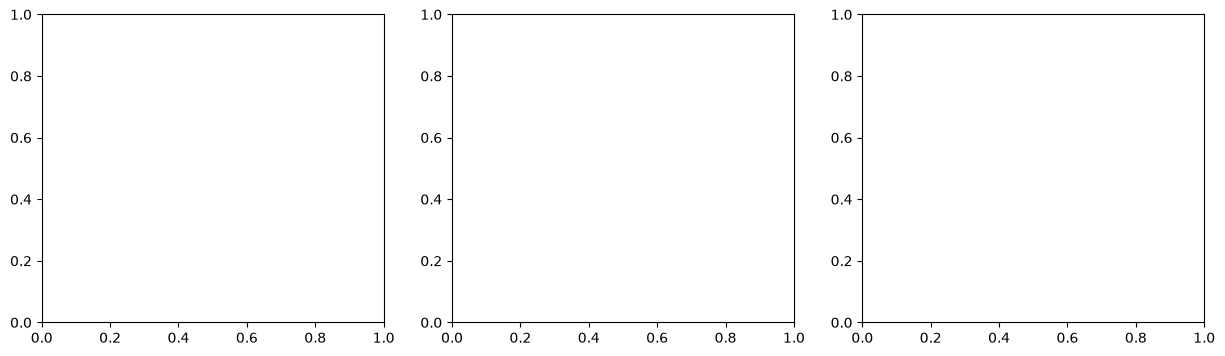

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

labels = [["TN", "FP"], ["FN", "TP"]]

fig_confusion, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (model_name, model) in zip(axes, [
    ("Logistic Regression", log_reg),
    ("Random Forest", random_forest),
    ("XGBoost", xgboost_model),
]):
    y_pred = (model.predict_proba(X_validation)[:, 1] >= THRESHOLD).astype(int)
    cm = confusion_matrix(y_validation, y_pred)

    ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{labels[i][j]}\n{cm[i, j]}", ha="center", va="center")

    ax.set_xticks([0, 1], ["False", "True"])
    ax.set_yticks([0, 1], ["False", "True"])
    ax.set_xlabel("Prédit")
    ax.set_ylabel("Réel")
    ax.set_title(f"{model_name}\n(seuil={THRESHOLD})")

plt.tight_layout()
plt.show()

## Recall des 3 modèles au seuil choisi

On calcule le recall (rappel) de chaque modèle sur `df_validation`, au seuil `THRESHOLD` — la part des vraies pannes effectivement détectées.

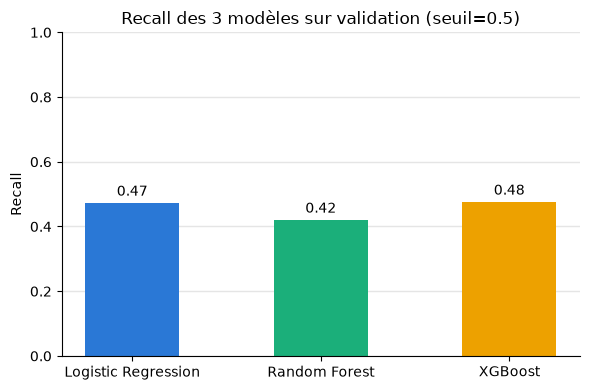

In [62]:
from sklearn.metrics import recall_score

models = [
    ("Logistic Regression", log_reg),
    ("Random Forest", random_forest),
    ("XGBoost", xgboost_model),
]
model_colors = ["#2a78d6", "#1baf7a", "#eda100"]

recalls = [
    recall_score(y_validation, (model.predict_proba(X_validation)[:, 1] >= THRESHOLD).astype(int))
    for _, model in models
]

fig_recall, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar([name for name, _ in models], recalls, color=model_colors, width=0.5)
ax.bar_label(bars, fmt="%.2f", padding=3)

ax.set_ylim(0, 1)
ax.set_ylabel("Recall")
ax.set_title(f"Recall des 3 modèles sur validation (seuil={THRESHOLD})")
ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.grid(True, color="#e5e5e5", linewidth=1)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## Comparaison du recall et de l'accuracy selon le seuil (0.1 à 0.5)

On compare le recall et l'accuracy des 3 modèles sur `df_validation` pour `THRESHOLD_RANGE`, afin de visualiser le compromis rappel/précision globale selon le seuil choisi.

In [63]:
from sklearn.metrics import recall_score, accuracy_score

metrics_by_threshold = []
for t in THRESHOLD_RANGE:
    for model_name, model in [
        ("Logistic Regression", log_reg),
        ("Random Forest", random_forest),
        ("XGBoost", xgboost_model),
    ]:
        y_pred = (model.predict_proba(X_validation)[:, 1] >= t).astype(int)
        metrics_by_threshold.append({
            "threshold": round(t, 1),
            "model": model_name,
            "recall": round(recall_score(y_validation, y_pred), 2),
            "accuracy": round(accuracy_score(y_validation, y_pred), 2),
        })

metrics_df = pd.DataFrame(metrics_by_threshold)


def color_scale(val):
    if val >= 0.75:
        color = "#c6efce"  # vert
    elif val >= 0.5:
        color = "#ffeb9c"  # jaune
    elif val >= 0.25:
        color = "#ffd699"  # orange
    else:
        color = "#ffc7ce"  # rouge
    return f"background-color: {color}; color: black"


print("Recall")
display(metrics_df.pivot(index="model", columns="threshold", values="recall").style.map(color_scale).format("{:.2f}"))

print("Accuracy")
display(metrics_df.pivot(index="model", columns="threshold", values="accuracy").style.map(color_scale).format("{:.2f}"))

Recall


threshold,0.100000,0.200000,0.300000,0.400000,0.500000
model,,,,,
Logistic Regression,1.00,0.98,0.74,0.54,0.47
Random Forest,0.76,0.61,0.53,0.48,0.42
XGBoost,0.78,0.64,0.56,0.52,0.48


Accuracy


threshold,0.100000,0.200000,0.300000,0.400000,0.500000
model,,,,,
Logistic Regression,0.17,0.19,0.57,0.79,0.83
Random Forest,0.53,0.70,0.78,0.83,0.87
XGBoost,0.51,0.65,0.73,0.79,0.82


## Suivi des modèles avec MLflow

On enregistre chaque modèle dans MLflow (backend SQLite `mlflow.db`, requis par MLflow 3.x qui a mis le backend fichier `mlruns/` en maintenance) : ses hyperparamètres (`get_params()`), ses métriques sur validation (recall, PR-AUC au seuil `THRESHOLD`), le modèle entraîné lui-même, ainsi que les graphiques de déséquilibre, matrice de confusion et recall en artefacts. À chaque changement d'hyperparamètre, relancer cette cellule crée un nouveau run comparable dans l'UI (`mlflow ui --backend-store-uri sqlite:///mlflow.db`), sans écraser les précédents.

In [62]:
import mlflow
import mlflow.sklearn
import mlflow.xgboost
from sklearn.metrics import accuracy_score

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT_NAME)

models_to_log = [
    ("logistic_regression_24h", log_reg, mlflow.sklearn),
    ("random_forest_24h", random_forest, mlflow.sklearn),
    ("xgboost_24h", xgboost_model, mlflow.xgboost),
]

for run_name, model, flavor in models_to_log:
    y_proba = model.predict_proba(X_validation)[:, 1]
    y_pred = (y_proba >= THRESHOLD).astype(int)

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(model.get_params())
        mlflow.log_param("threshold", round(THRESHOLD, 2))
        mlflow.log_metric("recall", round(recall_score(y_validation, y_pred), 2))
        mlflow.log_metric("accuracy", round(accuracy_score(y_validation, y_pred), 2))
        mlflow.log_metric("pr_auc", round(average_precision_score(y_validation, y_proba), 2))
        flavor.log_model(model, "model")
        mlflow.log_figure(fig_imbalance, "imbalance.png")
        mlflow.log_figure(fig_confusion, "confusion_matrix.png")
        mlflow.log_figure(fig_recall, "recall.png")

print("Runs enregistrés. Lancer `mlflow ui --backend-store-uri sqlite:///mlflow.db` pour les consulter.")

2026/07/07 15:27:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/07 15:27:06 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/avallet/formation-ia-project
2026/07/07 15:27:06 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/avallet/formation-ia-project
2026/07/07 15:27:06 INFO mlflow.utils.environment: Detected uv project at /Users/avallet/formation-ia-project. Attempting to export requirements via 'uv export'.
2026/07/07 15:27:06 INFO mlflow.utils.uv_utils: Exported 184 dependencies via uv
2026/07/07 15:27:06 INFO mlflow.utils.environment: Successfully exported 184 requirements from uv project. Skipping package capture based inference.
2026/07/07 15:27:08 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/07/07 15:27:09 WARNING mlflow.models.

Runs enregistrés. Lancer `mlflow ui --backend-store-uri sqlite:///mlflow.db` pour les consulter.


## Modèle final : Random Forest au seuil 0.5

In [64]:
final_random_forest = RandomForestClassifier(**RANDOM_FOREST_PARAMS)
final_random_forest.fit(X_train, y_train)

y_proba = final_random_forest.predict_proba(X_validation)[:, 1]
y_pred = (y_proba >= FINAL_THRESHOLD).astype(int)

print(f"recall={recall_score(y_validation, y_pred):.2f}")
print(f"accuracy={accuracy_score(y_validation, y_pred):.2f}")

recall=0.42
accuracy=0.87


## Recherche d'hyperparamètres : n_estimators (100 à 300) × max_depth (10 à 20)

On fait varier `n_estimators` (pas de 50) et `max_depth` (pas de 5) pour le Random Forest final, au seuil `FINAL_THRESHOLD`. Chaque combinaison est entraînée et loguée dans MLflow (mêmes métriques que précédemment : recall, accuracy, PR-AUC), pour comparer les runs dans l'UI.

In [ ]:
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT_NAME)

for n_estimators in N_ESTIMATORS_RANGE:
    for max_depth in MAX_DEPTH_RANGE:
        params = {**RANDOM_FOREST_PARAMS, "n_estimators": n_estimators, "max_depth": max_depth}
        model = RandomForestClassifier(**params)
        model.fit(X_train, y_train)

        y_proba = model.predict_proba(X_validation)[:, 1]
        y_pred = (y_proba >= FINAL_THRESHOLD).astype(int)

        recall = round(recall_score(y_validation, y_pred), 2)
        accuracy = round(accuracy_score(y_validation, y_pred), 2)
        pr_auc = round(average_precision_score(y_validation, y_proba), 2)

        with mlflow.start_run(run_name=f"random_forest_n{n_estimators}_d{max_depth}_24h"):
            mlflow.log_params(model.get_params())
            mlflow.log_param("threshold", round(FINAL_THRESHOLD, 2))
            mlflow.log_metric("recall", recall)
            mlflow.log_metric("accuracy", accuracy)
            mlflow.log_metric("pr_auc", pr_auc)
            mlflow.sklearn.log_model(model, "model")

        print(f"n_estimators={n_estimators}, max_depth={max_depth}: recall={recall}, accuracy={accuracy}, pr_auc={pr_auc}")

## Diagnostic d'overfitting du modèle retenu (train vs validation)

On entraîne le Random Forest retenu, régularisé pour limiter l'overfitting (`n_estimators=150`, `max_depth=10`, `min_samples_leaf=50`, `max_features="log2"`), et on compare recall / accuracy / PR-AUC entre train et validation, au seuil `FINAL_THRESHOLD`. Un écart faible entre les deux lignes indique que le modèle généralise bien. Par rapport à `max_depth=20`, la régularisation réduit fortement l'écart PR-AUC train/validation (de ~0.40 à ~0.10) sans perte notable de performance sur validation : la profondeur excessive ne faisait que mémoriser le train.

In [65]:
final_model = RandomForestClassifier(
    **RANDOM_FOREST_PARAMS,
    n_estimators=FINAL_N_ESTIMATORS,
    max_depth=FINAL_MAX_DEPTH,
    min_samples_leaf=FINAL_MIN_SAMPLES_LEAF,
    max_features=FINAL_MAX_FEATURES,
)
final_model.fit(X_train, y_train)

overfitting_results = []
for split_name, X, y_true in [
    ("train", X_train, y_train),
    ("validation", X_validation, y_validation),
]:
    y_proba = final_model.predict_proba(X)[:, 1]
    y_pred = (y_proba >= FINAL_THRESHOLD).astype(int)
    overfitting_results.append({
        "split": split_name,
        "recall": round(recall_score(y_true, y_pred), 2),
        "accuracy": round(accuracy_score(y_true, y_pred), 2),
        "pr_auc": round(average_precision_score(y_true, y_proba), 2),
    })

pd.DataFrame(overfitting_results).set_index("split")

,recall,accuracy,pr_auc
split,,,
train,0.65,0.89,0.73
validation,0.52,0.82,0.58


## Explicabilité des features avec SHAP

On explique les prédictions de `final_model` avec SHAP. Le `TreeExplainer` calcule, pour chaque prédiction, la contribution de chaque feature. Le summary plot (beeswarm) classe les features par importance globale et montre comment leurs valeurs (bleu = basses, rouge = hautes) poussent la prédiction vers "panne". On calcule les valeurs SHAP sur un échantillon de `X_validation` (le calcul complet serait long).

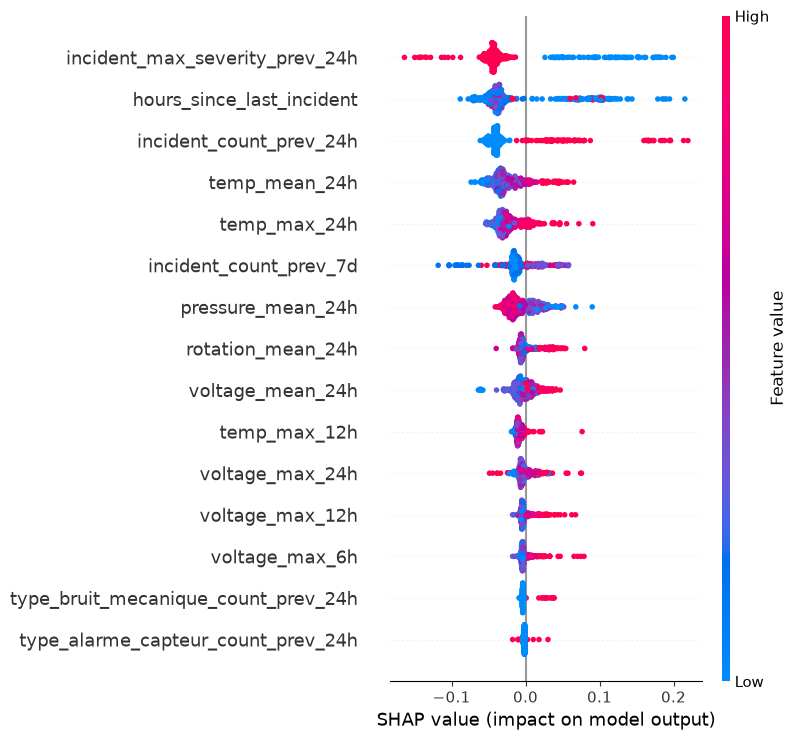

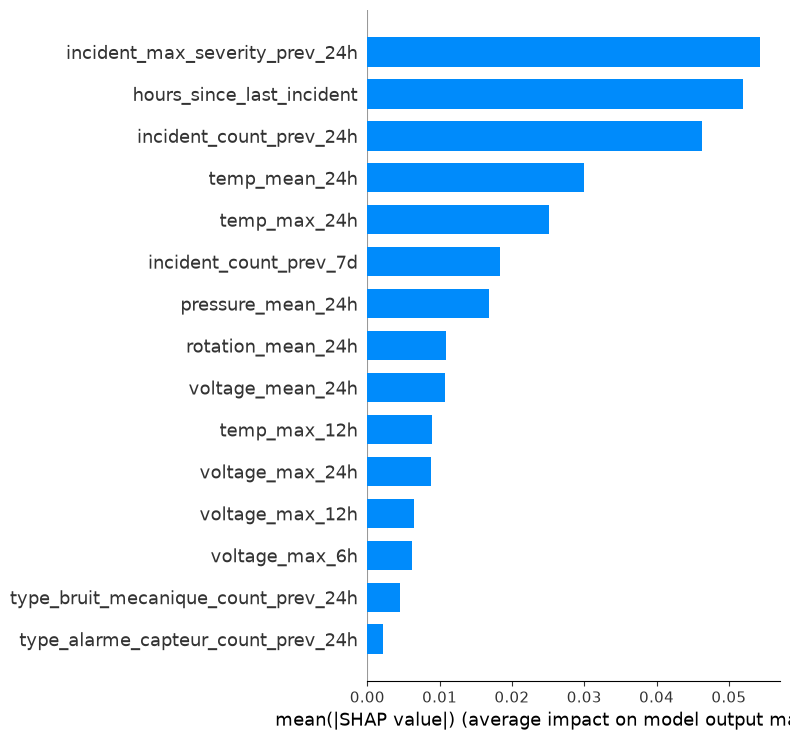

In [66]:
import shap

X_sample = X_validation.sample(n=500, random_state=RANDOM_STATE)

explainer = shap.TreeExplainer(final_model)
shap_values = explainer(X_sample)

# Classifieur binaire : on garde la classe positive (panne)
shap_values_positive = shap_values[:, :, 1]

# Beeswarm : impact + sens de chaque feature (valeur basse=bleu / haute=rouge)
shap.summary_plot(shap_values_positive, X_sample, max_display=len(feature_cols), show=True)

# Bar : importance globale (moyenne des |valeurs SHAP|)
shap.summary_plot(shap_values_positive, X_sample, plot_type="bar", max_display=len(feature_cols), show=True)

## Explication locale d'une instance (SHAP waterfall)

Le summary plot donne une vue globale ; ici on explique **une prédiction précise**. Le waterfall plot part de la valeur de base (moyenne des sorties du modèle) et montre, feature par feature, comment les valeurs de cette instance poussent la prédiction vers "panne" (rouge, +) ou "pas de panne" (bleu, −). On choisit ici la première instance de `X_sample` prédite comme panne au seuil `FINAL_THRESHOLD`.

Instance 11 (index 114087)
  proba de panne prédite : 0.94
  prédiction au seuil 0.5 : True
  vraie valeur (y)        : True
  valeurs des features :
voltage_max_6h                          230.870000
temp_max_12h                             57.192000
voltage_max_12h                         231.590000
temp_mean_24h                            49.853667
temp_max_24h                             57.192000
pressure_mean_24h                       199.251167
voltage_mean_24h                        229.683333
voltage_max_24h                         231.590000
rotation_mean_24h                      1648.074333
incident_count_prev_24h                   2.000000
incident_max_severity_prev_24h            3.000000
incident_count_prev_7d                    7.000000
hours_since_last_incident                23.000000
type_bruit_mecanique_count_prev_24h       0.000000
type_alarme_capteur_count_prev_24h        0.000000


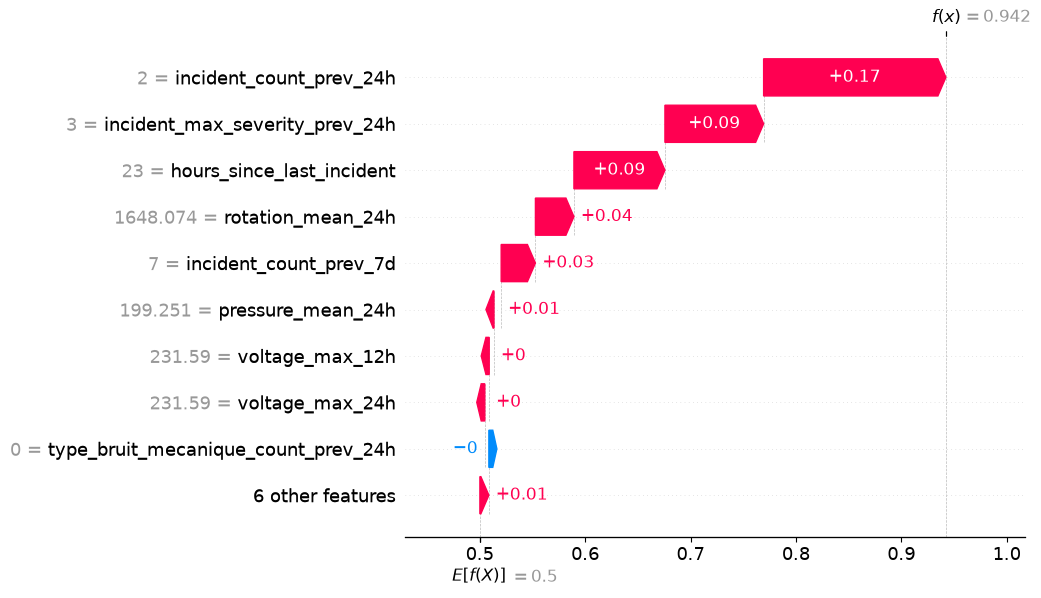

In [67]:
# Probabilité de panne prédite pour chaque instance de l'échantillon
sample_proba = final_model.predict_proba(X_sample)[:, 1]

# Première instance prédite comme panne au seuil FINAL_THRESHOLD (sinon la plus à risque)
positive_idx = np.where(sample_proba >= FINAL_THRESHOLD)[0]
instance_pos = positive_idx[0] if len(positive_idx) else int(sample_proba.argmax())

# Détails de l'instance expliquée
instance_row = X_sample.iloc[instance_pos]
instance_true_label = y_validation.loc[X_sample.index[instance_pos]]

print(f"Instance {instance_pos} (index {X_sample.index[instance_pos]})")
print(f"  proba de panne prédite : {sample_proba[instance_pos]:.2f}")
print(f"  prédiction au seuil {FINAL_THRESHOLD} : {sample_proba[instance_pos] >= FINAL_THRESHOLD}")
print(f"  vraie valeur (y)        : {instance_true_label}")
print("  valeurs des features :")
print(instance_row.to_string())

# Waterfall pour la classe positive (panne) de cette instance
shap.plots.waterfall(shap_values_positive[instance_pos], show=True)